## Safe@Sea wave and vessel icing forecast visualization

The Safe@Sea service provides wave and vessel icing forecasts at 1 km resolution in the Barents Sea. With high resolution of the Extremes DT, the new product provides forecasts that capture the hazardous ocean conditions at unprecedented detail.

The product is updated once a day and provides integral wave parameters together with spray icing rate. The product is developed for ECMWF/DestinationEarth by the Norwegian Meteorological Institute and Finnish Meteorological Institute.
    
The data is saved as .zarr files and the filenames are in the format `<var>_<date>T0000Z_<date+2>T0000Z_SafeAtSea.zarr`
where `<date>` has format `YYYYMMDD` and `<date+2>` is the day after the following day.

The service provides the following new variables (`<var>`):
* `swhw` - Significant height of wind waves (m)
* `swhs` - Significant height of swell waves (m)
* `swh` - Significant height of wind and swell waves (m)
* `pwdw` - Peak direction of wind waves (degree)
* `pwds` - Peak direction of swell waves (degree)
* `pwd` - Wave peak direction (degree)
* `pp2dw` - Swell wave period (s)
* `mwp` - Mean wave period (s)
* `mwd` - Mean wave direction (degree)
* `icing` - Vessel icing (mm/h)
* `dpt` - Sea depth (m)
* `pp1d` - Peak period of wind and swell waves (s)
* `pp1ds` - Peak period of swell waves (s)
* `pp1dw` - Peak period of wind waves (s)

In addition, for completeness, the following Extremes DT variables are provided (interpolated to the wave model grid) as part of the service output:

* `vwnd` - Northward wind (m/s)
* `uwnd` - Eastward wind (m/s)
* `ice` - Sea ice fraction (fraction)

NOTE THAT TO BE ABLE TO USE THIS NOTEBOOK, YOU NEED TO HAVE ZARR 3 INSTALLED IN YOUR ENVIRONMENT.

## This notebook:
- Loads wave and vessel icing forecast data
- Produces a visualization 

## Load modules

In [1]:
import sys, os 
import datetime

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from matplotlib.animation import FuncAnimation

## Specify file properties

In [6]:
var = 'icing'
date = '20260218'

start_date = datetime.date.fromisoformat(date)
end_date = start_date + datetime.timedelta(days=2)
dateformat = '%Y%m%d'

fname = f"{var}_{start_date.strftime(dateformat)}T0000Z_{end_date.strftime(dateformat)}T0000Z_SafeAtSea.zarr"
path = "https://safeatsea.s3.gra.io.cloud.ovh.net"
infile = os.path.join(path, fname)

## Access data

In [7]:
ds = xr.open_zarr(
    f"https://safeatsea.s3.gra.io.cloud.ovh.net/{fname}",
    consolidated=True,
    zarr_format=2
)

In [8]:
ds

<xarray.Dataset> Size: 226MB
Dimensions:  (time: 49, lat: 1402, lon: 823)
Coordinates:
  * time     (time) datetime64[ns] 392B 2026-02-18 ... 2026-02-20
  * lat      (lat) float64 11kB 68.0 68.01 68.02 68.03 ... 80.53 80.54 80.55
  * lon      (lon) float64 7kB 5.651 5.684 5.717 5.751 ... 32.98 33.02 33.05
Data variables:
    icing    (time, lat, lon) float32 226MB dask.array<chunksize=(7, 176, 206), meta=np.ndarray>
Attributes:
    product_name:  Safe@Sea 1km operational wave model forecast product
    title:         Safe@Sea 1km / operational wave forecast
    area:          1km operational domain covering: Barents Sea
    summary:       Safe@Sea is a numerical wave modelling system based on the...

## Plot example map visualization and save .png

In [19]:
for time in ds.time:
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection": ccrs.Orthographic(-15,60)})
    levels = [0,1,2,3,4,5,6,7,8,9]
    # domain = [ds.lon.min(), ds.lon.max(), ds.lat.min(), ds.lat.max()]
    im = ax.contourf(ds.lon.values, ds.lat.values, ds[var].sel(time=time).values, vmin=0,levels=levels, transform = ccrs.PlateCarree())
    ax.coastlines()
    ax.set_facecolor('lightgrey')
    plt.title(f'{var} at {str(time.values)[:13]}')
    ax.gridlines(xlocs=range(-180,180,10),ylocs=range(-90,90,10), color='black', linestyle='dotted', draw_labels=True)
    cbar_ax = fig.add_axes([0.85, 0.12, 0.05, 0.7])
    if var == 'icing':
        cbar_ax.set_title('$'+'[mm/h]'+'$')
    fig.colorbar(im, cax=cbar_ax)
    plt.savefig(f'{var}_{str(time.values)[:13]}_SafeAtSea.png',bbox_inches = 'tight')
    plt.close()

/home/jovyan/new_env/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


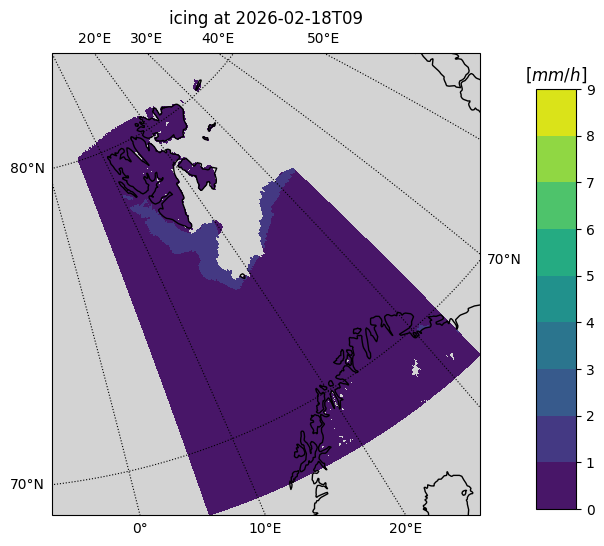

In [20]:
fig

## Plot animation and save .gif

MovieWriter Pillow unavailable; using Pillow instead.


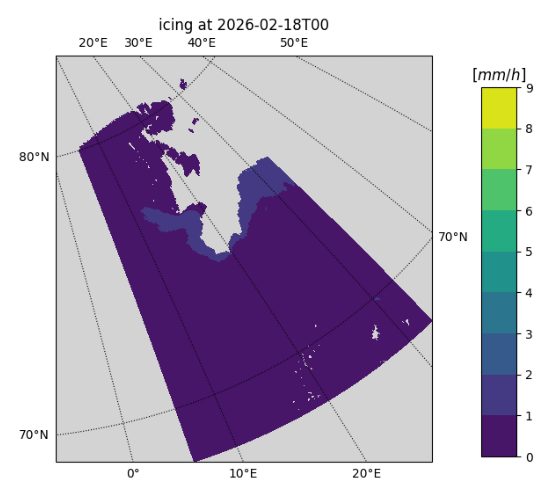

In [17]:
nframes = len(ds.time)
plt.subplots_adjust(top=1, bottom=0, left=0, right=1)

def animate(i):
    im = plt.imread(f'icing_{str(ds.time[i].values)[:13]}_SafeAtSea.png')
    plt.axis('off')  # remove axes for cleaner look
    plt.imshow(im)

anim = FuncAnimation(plt.gcf(), animate, frames=nframes, 
                     interval=(4000.0/nframes))


# Need to test on Insula how the animation can be shown as this can depend on installation
from IPython.display import HTML
HTML(anim.to_jshtml())

anim.save(f'{var}__{start_date.strftime(dateformat)}T0000Z_{end_date.strftime(dateformat)}T2000Z_SafeAtSea.gif', writer='Pillow')

# Comment out if you want to keep individual frames
#for time in ds.time[:10]:
#    os.remove(f'{var}_{str(time.values)[:13]}_SafeAtSea.png')